<a href="https://colab.research.google.com/github/PCY1124/AIFFEL_quest_rs/blob/main/Exploration/Ex6/NSMC_SentencePiece.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NSMC 감정 분석 실험 노트북

이 노트북은 네이버 영화 리뷰 감정 분석(NSMC) 데이터를 사용하여 토크나이저 종류 및 설정에 따른 성능 비교 실험을 수행합니다.

### **주요 미션 및 목표**
1. **SentencePiece 모델 학습**: 네이버 영화리뷰 코퍼스를 사용하여 SentencePiece 서브워드 기반 모델을 학습합니다.
2. **토크나이저 구현**: 학습된 SentencePiece 모델을 활용하여 `sp_tokenize()` 메소드를 직접 구현합니다.
3. **감정 분석 모델 학습**: 구현한 토크나이저를 적용하여 LSTM 기반 감정 분석 모델을 학습합니다.
4. **형태소 분석기 비교**: KoNLPy의 다양한 형태소 분석기(Mecab, Okt, Kkma)를 사용한 모델과 성능을 정량적으로 비교합니다.
5. **성능 개선 실험**: SentencePiece의 `model_type`(Unigram, BPE) 및 `vocab_size` 설정을 변경하며 최적의 구성을 탐색합니다.


## 단계 0. 환경 준비

환경 준비 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 0. 환경 준비
# ============================================
import sys
import os
import re
import ssl
import random
import urllib.request
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm
from sklearn.model_selection import train_test_split


!pip install konlpy sentencepiece scikit-learn matplotlib pandas

try:
    from konlpy.tag import Okt, Mecab, Kkma
except ImportError:
    print("KoNLPy가 설치되지 않았습니다. !pip install konlpy 실행 필요")




   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 40.3 MB/s eta 0:00:00


## 단계 1. 재현성 고정

재현성 고정 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 1. 재현성 고정
# ============================================
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 재현성 강화
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)




## 단계 2. 장치 확인

장치 확인 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 2. 장치 확인
# ============================================
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA 사용 가능:", torch.cuda.get_device_name(torch.cuda.current_device()))
else:
    device = torch.device("cpu")
    print("CUDA 사용 불가 -> CPU 사용")

print("사용 장치:", device)
print("Python:", sys.version)
print("Torch:", torch.__version__)
print("NumPy:", np.__version__)
print("SentencePiece:", spm.__version__)




CUDA 사용 가능: Tesla T4
사용 장치: cuda
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.10.0+cu128
NumPy: 2.0.2
SentencePiece: 0.2.1


## 단계 3. NSMC 데이터 다운로드 및 로드

NSMC 데이터 다운로드 및 로드 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 3. NSMC 데이터 다운로드 및 로드
# ============================================
ssl._create_default_https_context = ssl._create_unverified_context

data_dir = Path("./nsmc_data")
data_dir.mkdir(exist_ok=True)

train_url = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt"
test_url  = "https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt"

train_path = data_dir / "ratings_train.txt"
test_path  = data_dir / "ratings_test.txt"

if not train_path.exists():
    urllib.request.urlretrieve(train_url, train_path)
    print("ratings_train.txt 다운로드 완료")
else:
    print("ratings_train.txt 이미 존재")

if not test_path.exists():
    urllib.request.urlretrieve(test_url, test_path)
    print("ratings_test.txt 다운로드 완료")
else:
    print("ratings_test.txt 이미 존재")


def load_nsmc(path: Path) -> pd.DataFrame:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        next(f)  # header skip
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) == 3:
                rows.append({
                    "id": parts[0],
                    "text": parts[1],
                    "label": int(parts[2])
                })
    return pd.DataFrame(rows)


train_df = load_nsmc(train_path)
test_df = load_nsmc(test_path)

print("원본 train shape:", train_df.shape)
print("원본 test shape:", test_df.shape)
print(train_df["label"].value_counts())




ratings_train.txt 다운로드 완료
ratings_test.txt 다운로드 완료
원본 train shape: (150000, 3)
원본 test shape: (50000, 3)
label
0    75173
1    74827
Name: count, dtype: int64


## 단계 4. 텍스트 전처리

텍스트 전처리 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 4. 텍스트 전처리
# ============================================
def clean_text(text: str) -> str:
    text = re.sub(r"[^가-힣ㄱ-ㅎㅏ-ㅣ0-9\s]", " ", str(text))
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["cleaned_text"] = train_df["text"].apply(clean_text)
test_df["cleaned_text"] = test_df["text"].apply(clean_text)

train_df = train_df[train_df["cleaned_text"].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df["cleaned_text"].str.len() > 0].reset_index(drop=True)

train_df["text_len"] = train_df["cleaned_text"].apply(len)
test_df["text_len"] = test_df["cleaned_text"].apply(len)

print("정제 후 train shape:", train_df.shape)
print("정제 후 test shape:", test_df.shape)
print(train_df["text_len"].describe())




정제 후 train shape: (148886, 5)
정제 후 test shape: (49630, 5)
count    148886.000000
mean         32.968593
std          28.386503
min           1.000000
25%          14.000000
50%          25.000000
75%          40.000000
max         140.000000
Name: text_len, dtype: float64


## 단계 5. train / valid 분할

train / valid 분할 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 5. train / valid 분할
#    test는 끝까지 건드리지 않음
# ============================================
train_df_split, valid_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

print("train split:", train_df_split.shape)
print("valid split:", valid_df.shape)
print("test set:", test_df.shape)




train split: (119108, 5)
valid split: (29778, 5)
test set: (49630, 5)


## 단계 6. SentencePiece 학습용 코퍼스 저장

SentencePiece 학습용 코퍼스 저장 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 6. SentencePiece 학습용 코퍼스 저장
#    train split만 사용 (data leakage 방지)
# ============================================
sp_dir = Path("./sentencepiece_models")
sp_dir.mkdir(exist_ok=True)

corpus_file = sp_dir / "nsmc_train_corpus.txt"
with open(corpus_file, "w", encoding="utf-8") as f:
    for text in train_df_split["cleaned_text"]:
        f.write(text + "\n")

print("SentencePiece 학습 코퍼스 저장 완료:", corpus_file)




SentencePiece 학습 코퍼스 저장 완료: sentencepiece_models/nsmc_train_corpus.txt


## 단계 7. SentencePiece 학습 함수 [미션 1, 5]

SentencePiece는 Google에서 공개한 비지도 학습 기반의 토크나이저로, 사전(Dictionary) 없이 말뭉치에서 자주 등장하는 데이터 단위를 추출하여 서브워드(Subword)를 분리합니다.

### 주요 파라미터 설명:
- **model_type**: 서브워드를 분리하는 알고리즘을 설정합니다.
    - `unigram`: 확률 기반으로 가장 점수가 높은 서브워드 조합을 선택합니다. (기본값)
    - `bpe`: 빈도 기반으로 가장 자주 나타나는 문자 쌍을 병합합니다. (Byte Pair Encoding)
- **vocab_size**: 추출할 서브워드의 최대 개수를 설정합니다. 너무 작으면 단어 분절이 너무 많이 일어나고, 너무 크면 모델이 복잡해집니다.
- **character_coverage**: 모델이 커버할 문자의 비율입니다. 한글은 1.0(또는 0.9995)을 권장합니다.


In [ ]:
# ============================================
# 7. SentencePiece 학습 함수
# ============================================
def train_sentencepiece(
    corpus_path: Path,
    model_prefix: str,
    vocab_size: int = 8000,
    model_type: str = "unigram",
    character_coverage: float = 0.9995,
    input_sentence_size: int = 200000,
    shuffle_input_sentence: bool = True
):
    prefix_path = str(sp_dir / model_prefix)

    # 이미 모델이 있으면 재학습 생략 가능
    model_file = Path(prefix_path + ".model")
    vocab_file = Path(prefix_path + ".vocab")
    if model_file.exists() and vocab_file.exists():
        print(f"[SKIP] 이미 존재: {model_prefix}")
        return prefix_path

    options = (
        f"--input={corpus_path} "
        f"--model_prefix={prefix_path} "
        f"--vocab_size={vocab_size} "
        f"--model_type={model_type} "
        f"--character_coverage={character_coverage} "
        f"--input_sentence_size={input_sentence_size} "
        f"--shuffle_input_sentence={'true' if shuffle_input_sentence else 'false'} "
        f"--unk_id=0 "
        f"--pad_id=1 "
        f"--bos_id=-1 "
        f"--eos_id=-1"
    )

    spm.SentencePieceTrainer.Train(options)
    print(f"[DONE] SentencePiece 학습 완료: {model_prefix}")
    return prefix_path


sp_configs = [
    {"label": "Unigram 8000",  "prefix": "nsmc_unigram_8000",  "vocab_size": 8000,  "model_type": "unigram"},
    {"label": "BPE 8000",      "prefix": "nsmc_bpe_8000",      "vocab_size": 8000,  "model_type": "bpe"},
    {"label": "Unigram 4000",  "prefix": "nsmc_unigram_4000",  "vocab_size": 4000,  "model_type": "unigram"},
    {"label": "Unigram 16000", "prefix": "nsmc_unigram_16000", "vocab_size": 16000, "model_type": "unigram"},
]

for cfg in sp_configs:
    train_sentencepiece(
        corpus_path=corpus_file,
        model_prefix=cfg["prefix"],
        vocab_size=cfg["vocab_size"],
        model_type=cfg["model_type"]
    )




[DONE] SentencePiece 학습 완료: nsmc_unigram_8000
[DONE] SentencePiece 학습 완료: nsmc_bpe_8000
[DONE] SentencePiece 학습 완료: nsmc_unigram_4000
[DONE] SentencePiece 학습 완료: nsmc_unigram_16000


## 단계 8. SentencePiece 토크나이저 구현 [미션 2]

학습된 SentencePiece 모델을 사용하여 텍스트를 인덱스 시퀀스로 변환하는 `sp_tokenize()` 함수를 구현합니다.

### 구현 핵심 내용:
1. **EncodeAsIds**: 문장을 사전에 정의된 정수 인덱스 리스트로 변환합니다.
2. **Truncation**: `max_length`보다 긴 문장은 뒷부분을 잘라내어 길이를 제한합니다.
3. **Padding**: 서로 다른 길이의 문장들을 배치(Batch) 단위로 처리하기 위해 `pad_sequence`를 사용하여 길이를 맞춥니다. 여기서는 `pad_id=1`을 사용합니다.


In [ ]:
# ============================================
# 8. SentencePiece 토크나이저 구현
# ============================================
def sp_tokenize(sp_processor, texts, max_length: int = 100):
    sequences = []
    for text in texts:
        ids = sp_processor.EncodeAsIds(text)
        ids = ids[:max_length]
        sequences.append(torch.tensor(ids, dtype=torch.long))

    return pad_sequence(sequences, batch_first=True, padding_value=1)  # pad_id=1


# 사용 예시
sp_example = spm.SentencePieceProcessor()
sp_example.Load(str(sp_dir / "nsmc_unigram_8000.model"))

example_texts = [
    "이 영화는 정말 재미있고 감동적입니다",
    "스토리가 지루하고 연출도 별로였어요"
]

example_tensor = sp_tokenize(sp_example, example_texts, max_length=32)
print("sp_tokenize 결과 shape:", example_tensor.shape)
print("예시 pieces:", sp_example.EncodeAsPieces(example_texts[0]))




sp_tokenize 결과 shape: torch.Size([2, 5])
예시 pieces: ['▁이', '▁영화는', '▁정말', '▁재미있고', '▁감동적입니다']


## 단계 9. 공통 Dataset / Collate

공통 Dataset / Collate 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 9. 공통 Dataset / Collate
# ============================================
class IndexedTextDataset(Dataset):
    """
    이미 숫자 인덱스로 변환된 시퀀스를 받는 공통 Dataset
    """
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.sequences[idx], dtype=torch.long),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )


def collate_fn(batch, pad_value=1):
    texts, labels = zip(*batch)
    texts = pad_sequence(texts, batch_first=True, padding_value=pad_value)
    labels = torch.stack(labels)
    return texts, labels




## 단계 10. 모델 정의

모델 정의 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 10. 모델 정의
# ============================================
class TextClassifier(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 128,
        hidden_dim: int = 256,
        output_dim: int = 2,
        n_layers: int = 2,
        dropout: float = 0.3,
        padding_idx: int = 1
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )

        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)

        # 양방향 LSTM 마지막 hidden concat
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        logits = self.fc(hidden_cat)
        return logits




## 단계 11. 학습 / 평가 함수

학습 / 평가 함수 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 11. 학습 / 평가 함수
# ============================================
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for texts, labels in loader:
        texts = texts.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        preds = model(texts)
        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        correct += (preds.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    avg_acc = correct / total
    return avg_loss, avg_acc


def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for texts, labels in loader:
            texts = texts.to(device)
            labels = labels.to(device)

            preds = model(texts)
            loss = criterion(preds, labels)

            total_loss += loss.item() * labels.size(0)
            correct += (preds.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    avg_acc = correct / total
    return avg_loss, avg_acc


def fit_model(
    model,
    train_loader,
    valid_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    epochs: int = 5,
    save_path: str = "best_model.pt"
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "valid_loss": [],
        "valid_acc": []
    }

    best_valid_acc = 0.0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        valid_loss, valid_acc = evaluate(model, valid_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        print(
            f"[Epoch {epoch+1}/{epochs}] "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"valid_loss={valid_loss:.4f}, valid_acc={valid_acc:.4f}"
        )

        if valid_acc > best_valid_acc:
            best_valid_acc = valid_acc
            torch.save(model.state_dict(), save_path)

    # best model 로드 후 test 1회 평가
    model.load_state_dict(torch.load(save_path, map_location=device))
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    return history, best_valid_acc, test_loss, test_acc




## 단계 12. SentencePiece용 인덱스 시퀀스 생성

SentencePiece용 인덱스 시퀀스 생성 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 12. SentencePiece용 인덱스 시퀀스 생성
# ============================================
def encode_with_sentencepiece(df: pd.DataFrame, sp_processor, max_length: int = 100):
    sequences = []
    labels = df["label"].tolist()

    for text in df["cleaned_text"].tolist():
        ids = sp_processor.EncodeAsIds(text)
        ids = ids[:max_length]
        sequences.append(ids)

    return sequences, labels




## 단계 13. KoNLPy용 토큰화 + vocab 생성 + 인덱싱 [미션 4]

비교 실험을 위해 한국어 전통 형태소 분석 라이브러리인 KoNLPy를 사용합니다.

### SentencePiece vs KoNLPy 차이점:
- **KoNLPy (Morpheme-based)**: 사람이 정의한 문법 규칙과 사전을 바탕으로 문장을 형태소 단위로 쪼갭니다. 한국어의 언어적 특징(조사, 어미 등)을 명확히 반영하지만, 신조어나 오탈자 처리에 취약할 수 있습니다.
- **SentencePiece (Subword-based)**: 순수하게 통계적인 빈도를 바탕으로 의미를 가진 최소 단위(서브워드)를 찾아냅니다. 사전이 불필요하며 신조어나 데이터 기반 처리에 강점이 있습니다.


In [ ]:
# ============================================
# 13. KoNLPy용 토큰화 + vocab 생성 + 인덱싱
#     (캐싱 적용)
# ============================================
def tokenize_konlpy_texts(texts, tokenizer):
    tokenized = []
    for text in texts:
        morphs = tokenizer.morphs(text)
        tokenized.append(morphs)
    return tokenized


def build_word_index_from_tokenized(tokenized_texts, min_freq: int = 2, pad_idx: int = 1, unk_idx: int = 0):
    freq = Counter()
    for tokens in tokenized_texts:
        freq.update(tokens)

    word_index = {"<UNK>": unk_idx, "<PAD>": pad_idx}
    current_idx = 2

    for word, count in freq.items():
        if count >= min_freq:
            word_index[word] = current_idx
            current_idx += 1

    return word_index


def encode_tokenized_texts(tokenized_texts, word_index, max_length: int = 100):
    sequences = []
    for tokens in tokenized_texts:
        ids = [word_index.get(token, 0) for token in tokens]  # OOV -> UNK(0)
        ids = ids[:max_length]
        sequences.append(ids)
    return sequences




## 단계 14. DataLoader 생성 함수

DataLoader 생성 함수 코드를 실행하고 출력 결과를 확인합니다.


In [ ]:
# ============================================
# 14. DataLoader 생성 함수
# ============================================
def make_dataloader(sequences, labels, batch_size=64, shuffle=False, pad_value=1):
    dataset = IndexedTextDataset(sequences, labels)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=lambda batch: collate_fn(batch, pad_value=pad_value)
    )




## 단계 15. 공통 실험 하이퍼파라미터

공통 실험 하이퍼파라미터 코드를 설정


In [ ]:
# ============================================
# 15. 공통 실험 하이퍼파라미터
# ============================================
BATCH_SIZE = 64
EMBEDDING_DIM = 128
HIDDEN_DIM = 256
N_LAYERS = 2
DROPOUT = 0.3
LR = 1e-3
EPOCHS = 5
MAX_LENGTH = 100

criterion = nn.CrossEntropyLoss()




## 단계 16. SentencePiece 실험 함수

SentencePiece 실험 함수 코드를 실행하고 출력 결과를 확인


In [ ]:
# ============================================
# 16. SentencePiece 실험 함수
# ============================================
def run_sentencepiece_experiment(config):
    print("\n" + "=" * 70)
    print(f"[SentencePiece 실험] {config['label']}")
    print("=" * 70)

    sp_proc = spm.SentencePieceProcessor()
    model_path = str(sp_dir / f"{config['prefix']}.model")
    sp_proc.Load(model_path)

    train_seq, train_labels = encode_with_sentencepiece(train_df_split, sp_proc, max_length=MAX_LENGTH)
    valid_seq, valid_labels = encode_with_sentencepiece(valid_df, sp_proc, max_length=MAX_LENGTH)
    test_seq, test_labels = encode_with_sentencepiece(test_df, sp_proc, max_length=MAX_LENGTH)

    train_loader = make_dataloader(train_seq, train_labels, batch_size=BATCH_SIZE, shuffle=True,  pad_value=1)
    valid_loader = make_dataloader(valid_seq, valid_labels, batch_size=BATCH_SIZE, shuffle=False, pad_value=1)
    test_loader  = make_dataloader(test_seq,  test_labels,  batch_size=BATCH_SIZE, shuffle=False, pad_value=1)

    model = TextClassifier(
        vocab_size=sp_proc.vocab_size(),
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        output_dim=2,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
        padding_idx=1
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    save_path = f"best_{config['prefix']}.pt"
    history, best_valid_acc, test_loss, test_acc = fit_model(
        model=model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        test_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        save_path=save_path
    )

    result = {
        "tokenizer": "SentencePiece",
        "config": config["label"],
        "vocab_size": sp_proc.vocab_size(),
        "best_valid_acc": best_valid_acc,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "history": history
    }
    return result




## 단계 17. KoNLPy 실험 함수 [미션 4]

KoNLPy 형태소 분석기를 사용하여 데이터를 준비하고 루프를 통해 LSTM 모델을 학습

### 분석기 탐색:
- **Mecab**: 속도가 가장 빠르며 성능이 우수하여 사실상 표준으로 사용
- **Okt (Open Korean Text)**: SNS 데이터나 영화 리뷰 같은 일상적인 문체 처리에 강점이 있음
- **Kkma (꼬꼬마)**: 분석은 매우 정확하지만 다른 분석기에 비해 속도가 현저히 느림


In [ ]:
# ============================================
# 17. KoNLPy 실험 함수
# ============================================
def run_konlpy_experiment(name, analyzer):
    print("\n" + "=" * 70)
    print(f"[KoNLPy 실험] {name}")
    print("=" * 70)

    # 1) 형태소 분석 결과 캐싱
    train_tokens = tokenize_konlpy_texts(train_df_split["cleaned_text"].tolist(), analyzer)
    valid_tokens = tokenize_konlpy_texts(valid_df["cleaned_text"].tolist(), analyzer)
    test_tokens  = tokenize_konlpy_texts(test_df["cleaned_text"].tolist(), analyzer)

    # 2) train 기준 vocab 생성
    word_index = build_word_index_from_tokenized(train_tokens, min_freq=2)

    # 3) 인덱싱
    train_seq = encode_tokenized_texts(train_tokens, word_index, max_length=MAX_LENGTH)
    valid_seq = encode_tokenized_texts(valid_tokens, word_index, max_length=MAX_LENGTH)
    test_seq  = encode_tokenized_texts(test_tokens,  word_index, max_length=MAX_LENGTH)

    train_labels = train_df_split["label"].tolist()
    valid_labels = valid_df["label"].tolist()
    test_labels  = test_df["label"].tolist()

    train_loader = make_dataloader(train_seq, train_labels, batch_size=BATCH_SIZE, shuffle=True,  pad_value=1)
    valid_loader = make_dataloader(valid_seq, valid_labels, batch_size=BATCH_SIZE, shuffle=False, pad_value=1)
    test_loader  = make_dataloader(test_seq,  test_labels,  batch_size=BATCH_SIZE, shuffle=False, pad_value=1)

    model = TextClassifier(
        vocab_size=len(word_index),
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        output_dim=2,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
        padding_idx=1
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    save_path = f"best_konlpy_{name}.pt"
    history, best_valid_acc, test_loss, test_acc = fit_model(
        model=model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        test_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        save_path=save_path
    )

    result = {
        "tokenizer": "KoNLPy",
        "config": name,
        "vocab_size": len(word_index),
        "best_valid_acc": best_valid_acc,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "history": history
    }
    return result




## 단계 18. SentencePiece 실험 실행 [미션 3, 5]

앞서 정의한 `sp_configs` 리스트의 다양한 설정을 순회하며 실험을 진행합니다.

### 성능 개선 포인트:
- **Vocab Size (4000 vs 8000 vs 16000)**: 사전 크기가 커질수록 더 긴 단위의 표현을 학습할 수 있지만, 모델 파라미터가 늘어나고 데이터 가 희소해질 수 있습니다.
- **Model Type (Unigram vs BPE)**: 적용 알고리즘에 따른 토큰 분절 양상을 확인하고 최적의 모델을 찾습니다.


In [ ]:
# ============================================
# 18. SentencePiece 실험 실행
# ============================================
sp_results = []
for config in sp_configs:
    result = run_sentencepiece_experiment(config)
    sp_results.append(result)

print("\nSentencePiece 실험 결과")
for r in sp_results:
    print(r["config"], " | valid_acc=", round(r["best_valid_acc"], 4), " | test_acc=", round(r["test_acc"], 4))





[SentencePiece 실험] Unigram 8000
[Epoch 1/5] train_loss=0.4744, train_acc=0.7653 | valid_loss=0.3763, valid_acc=0.8336
[Epoch 2/5] train_loss=0.3305, train_acc=0.8580 | valid_loss=0.3446, valid_acc=0.8507
[Epoch 3/5] train_loss=0.2788, train_acc=0.8843 | valid_loss=0.3334, valid_acc=0.8527
[Epoch 4/5] train_loss=0.2233, train_acc=0.9094 | valid_loss=0.3583, valid_acc=0.8542
[Epoch 5/5] train_loss=0.1672, train_acc=0.9339 | valid_loss=0.4060, valid_acc=0.8509

[SentencePiece 실험] BPE 8000
[Epoch 1/5] train_loss=0.4822, train_acc=0.7633 | valid_loss=0.3713, valid_acc=0.8349
[Epoch 2/5] train_loss=0.3332, train_acc=0.8562 | valid_loss=0.3399, valid_acc=0.8505
[Epoch 3/5] train_loss=0.2820, train_acc=0.8800 | valid_loss=0.3319, valid_acc=0.8534
[Epoch 4/5] train_loss=0.2320, train_acc=0.9046 | valid_loss=0.3592, valid_acc=0.8527
[Epoch 5/5] train_loss=0.1739, train_acc=0.9304 | valid_loss=0.4135, valid_acc=0.8515

[SentencePiece 실험] Unigram 4000
[Epoch 1/5] train_loss=0.4816, train_acc=0.76

## 단계 19. KoNLPy 분석기 준비

KoNLPy 분석기 준비 코드를 실행하고 출력 결과를 확인


In [ ]:
# ============================================
# 19. KoNLPy 분석기 준비
# ============================================
analyzers = {}

try:
    analyzers["Okt"] = Okt()
except Exception as e:
    print("Okt 로드 실패:", e)

try:
    analyzers["Mecab"] = Mecab()
except Exception as e:
    print("Mecab 로드 실패:", e)

try:
    analyzers["Kkma"] = Kkma()
except Exception as e:
    print("Kkma 로드 실패:", e)




Mecab 로드 실패: Install MeCab in order to use it: http://konlpy.org/en/latest/install/


## 단계 20. KoNLPy 실험 실행

KoNLPy 실험 실행 코드를 실행하고 출력 결과를 확인


In [ ]:
# ============================================
# 20. KoNLPy 실험 실행
# ============================================
konlpy_results_filtered = []
for name, analyzer in analyzers.items():
    if name == "Kkma":
        print(f"Kkma 실험은 요청에 따라 건너뜁니다.")
        continue
    result = run_konlpy_experiment(name, analyzer)
    konlpy_results_filtered.append(result)

print("\nKoNLPy 실험 결과")
for r in konlpy_results_filtered:
    print(r["config"], " | valid_acc=", round(r["best_valid_acc"], 4), " | test_acc=", round(r["test_acc"], 4))

konlpy_results = konlpy_results_filtered


[KoNLPy 실험] Okt
[Epoch 1/5] train_loss=0.4537, train_acc=0.7799 | valid_loss=0.3692, valid_acc=0.8310
[Epoch 2/5] train_loss=0.3152, train_acc=0.8648 | valid_loss=0.3439, valid_acc=0.8475
[Epoch 3/5] train_loss=0.2454, train_acc=0.8998 | valid_loss=0.3577, valid_acc=0.8516
[Epoch 4/5] train_loss=0.1807, train_acc=0.9290 | valid_loss=0.3902, valid_acc=0.8529
[Epoch 5/5] train_loss=0.1260, train_acc=0.9517 | valid_loss=0.5249, valid_acc=0.8495

[KoNLPy 실험] Kkma


KeyboardInterrupt: 

## 단계 21. 결과 정리 [미션 4, 5]

최종적으로 모든 토크나이저와 설정별 성능(Accuracy)을 한눈에 비교할 수 있도록 DataFrame으로 정리합니다. 이 단계에서 최종적인 '승자' 모델이 무엇인지, 그리고 SentencePiece 설정 변경이 성능 향상에 기여했는지 확인합니다.

In [ ]:
# ============================================
# 21. 결과 정리
# ============================================
all_results = sp_results + konlpy_results

df_results = pd.DataFrame([
    {
        "tokenizer": r["tokenizer"],
        "config": r["config"],
        "vocab_size": r["vocab_size"],
        "best_valid_acc": r["best_valid_acc"],
        "test_acc": r["test_acc"],
        "test_loss": r["test_loss"]
    }
    for r in all_results
])

df_results = df_results.sort_values(by="test_acc", ascending=False).reset_index(drop=True)

print("\n최종 비교 결과")
print(df_results)


최종 비교 결과
       tokenizer         config  vocab_size  best_valid_acc  test_acc  \
0  SentencePiece   Unigram 4000        4000        0.854120  0.854362   
1  SentencePiece   Unigram 8000        8000        0.854221  0.853798   
2         KoNLPy            Okt       40166        0.852912  0.852529   
3  SentencePiece       BPE 8000        8000        0.853415  0.851985   
4  SentencePiece  Unigram 16000       16000        0.851367  0.847491   

   test_loss  
0   0.352832  
1   0.361906  
2   0.389233  
3   0.335835  
4   0.414444  


## 단계 22. 시각화

시각화 코드를 실행하고 출력 결과를 확인

/tmp/ipykernel_2611/2670042197.py:9: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2611/2670042197.py:9: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2611/2670042197.py:9: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2611/2670042197.py:9: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2611/2670042197.py:9: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarni

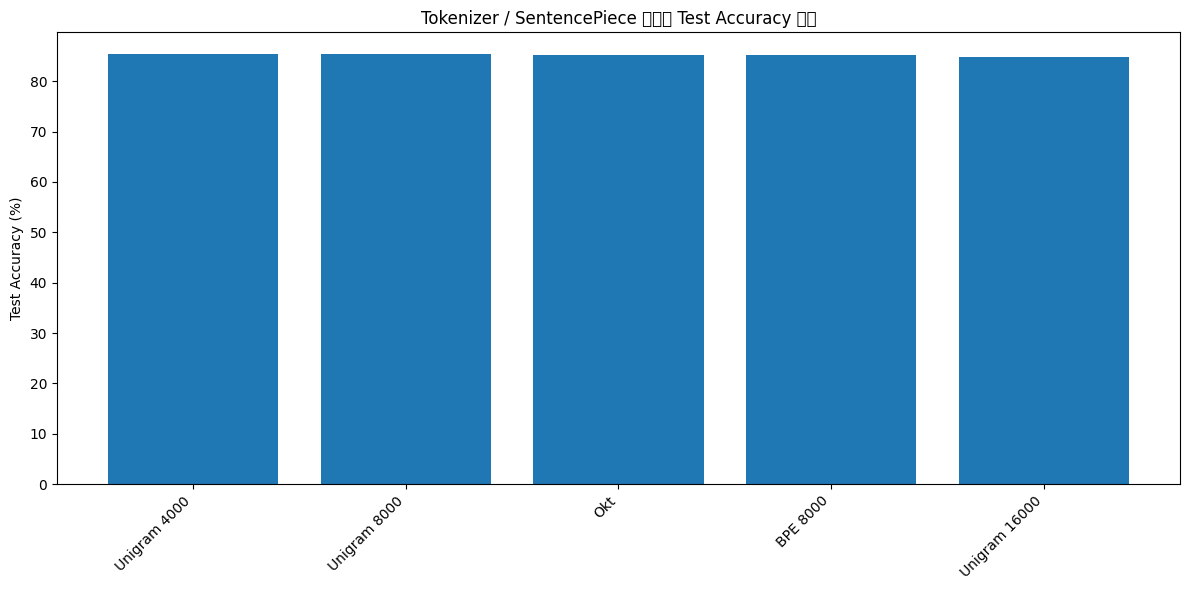

In [ ]:
# ============================================
# 22. 시각화
# ============================================
plt.figure(figsize=(12, 6))
plt.bar(df_results["config"], df_results["test_acc"] * 100)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy (%)")
plt.title("Tokenizer / SentencePiece 설정별 Test Accuracy 비교")
plt.tight_layout()
plt.show()

## 단계 23. 최고 성능 모델 확인

최고 성능 모델 확인 코드를 실행하고 출력 결과를 확인

In [ ]:
# ============================================
# 23. 최고 성능 모델 확인
# ============================================
best_row = df_results.iloc[0]
print("\n최고 성능 설정")
print(best_row)


최고 성능 설정
tokenizer         SentencePiece
config             Unigram 4000
vocab_size                 4000
best_valid_acc          0.85412
test_acc               0.854362
test_loss              0.352832
Name: 0, dtype: object


## 단계 24. 기본 SentencePiece 모델 학습곡선 시각화 예시

기본 SentencePiece 모델 학습곡선 시각화 예시 코드를 실행하고 출력 결과를 확인

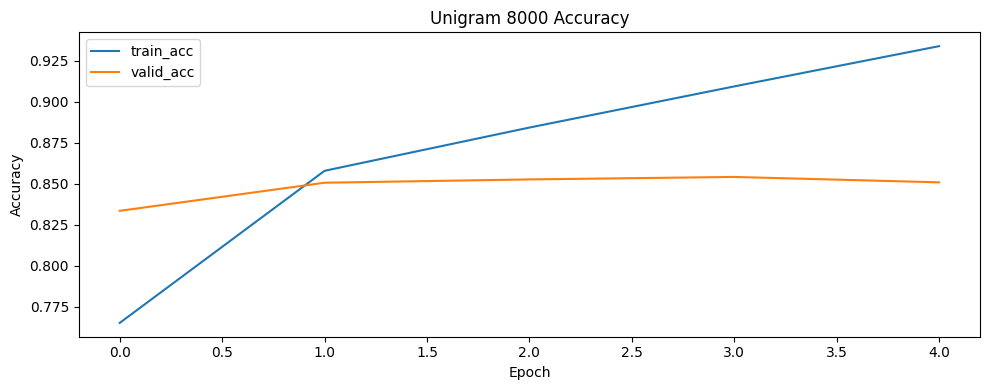

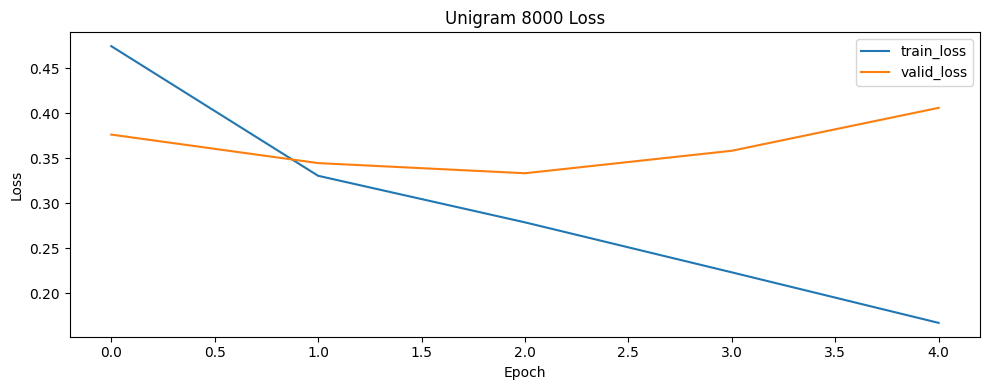

In [ ]:
  # ============================================
# 24. 기본 SentencePiece 모델 학습곡선 시각화 예시
# ============================================
# 예: Unigram 8000 history 보기
for r in sp_results:
    if r["config"] == "Unigram 8000":
        history = r["history"]

        plt.figure(figsize=(10, 4))
        plt.plot(history["train_acc"], label="train_acc")
        plt.plot(history["valid_acc"], label="valid_acc")
        plt.title("Unigram 8000 Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(history["train_loss"], label="train_loss")
        plt.plot(history["valid_loss"], label="valid_loss")
        plt.title("Unigram 8000 Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.tight_layout()
        plt.show()
        break

## 회고록

이번 실험을 통해 SentencePiece와 KoNLPy를 같은 조건에서 비교하며,  토크나이저 선택이 성능에 미치는 영향을 확인할 수 있었다.  
그러나 학습 속도가 너무 오래 걸리는 kkma와 설치가 제대로 되지 않았던 Mecab을 함께 비교하지 못한게 아쉬웠다.  
또한, SentencePiece의 결과가 생각보다 좋지 않아 아쉬웠다.  
그래서 노드에 언급됐던 내용인 vocab_size를 4000, 8000, 16000으로 변경을 해보았지만, 그렇게 큰 차이를 보이지는 않았다.  
그래서 embedding 모델을 Word2Vec을 이용한 실험까지 수행하기로 하였다.


## Bonus

## 단계 25. Word2Vec/GloVe 임베딩 + SentencePiece 실험 준비 (Bonus)

### 25-1. `gensim` 설치

In [ ]:
# ============================================
# 25-1. gensim 설치
# ============================================
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 67.3 MB/s eta 0:00:00


### 25-2. Word2Vec 학습용 코퍼스 준비 및 학습

In [ ]:
# ============================================
# 25-2. Word2Vec 학습용 코퍼스 준비 및 학습
# ============================================
from gensim.models import Word2Vec

# SentencePiece 모델 로드 (예시로 Unigram 8000 사용)
sp_w2v_processor = spm.SentencePieceProcessor()
sp_w2v_processor.Load(str(sp_dir / "nsmc_unigram_8000.model"))

# SentencePiece 토큰화된 코퍼스 준비
print("Word2Vec 학습용 코퍼스 토큰화 중...")
w2v_corpus = []
with open(corpus_file, "r", encoding="utf-8") as f:
    for line in f:
        tokens = sp_w2v_processor.EncodeAsPieces(line.strip())
        w2v_corpus.append(tokens)
print(f"총 {len(w2v_corpus)}개의 문장 토큰화 완료")

# Word2Vec 모델 학습
w2v_model = Word2Vec(
    sentences=w2v_corpus,
    vector_size=EMBEDDING_DIM, # 공통 임베딩 차원 사용
    window=5,
    min_count=5,
    workers=4,
    sg=1, # Skip-gram
    seed=42
)
w2v_model.save("nsmc_word2vec_unigram_8000.model")
print("Word2Vec 모델 학습 및 저장 완료: nsmc_word2vec_unigram_8000.model")

Word2Vec 학습용 코퍼스 토큰화 중...
총 119108개의 문장 토큰화 완료
Word2Vec 모델 학습 및 저장 완료: nsmc_word2vec_unigram_8000.model


### 25-2a. 'GloVe-like' Word2Vec 모델 학습 (CBOW)

In [ ]:
# ============================================
# 25-2a. 'GloVe-like' Word2Vec 모델 학습 (CBOW)
# ============================================
from gensim.models import Word2Vec

# Word2Vec (CBOW) 모델 학습 (GloVe-like)
glove_model = Word2Vec(
    sentences=w2v_corpus, # 동일한 코퍼스 사용
    vector_size=EMBEDDING_DIM,
    window=5,
    min_count=5,
    workers=4,
    sg=0, # CBOW (Continuous Bag-of-Words) 사용
    seed=42
)
glove_model.save("nsmc_glove_unigram_8000.model")
print("'GloVe-like' Word2Vec 모델 학습 및 저장 완료: nsmc_glove_unigram_8000.model")

'GloVe-like' Word2Vec 모델 학습 및 저장 완료: nsmc_glove_unigram_8000.model


### 25-3. 임베딩 행렬 생성 함수

In [ ]:
# ============================================
# 25-3. 임베딩 행렬 생성 함수
# ============================================
def create_embedding_matrix(
    sp_processor: spm.SentencePieceProcessor,
    w2v_model: Word2Vec,
    embedding_dim: int,
    padding_idx: int = 1
):
    vocab_size = sp_processor.vocab_size()
    embedding_matrix = np.random.uniform(-0.25, 0.25, (vocab_size, embedding_dim))

    # SP 토큰과 Word2Vec 벡터 매핑
    for i in range(vocab_size):
        token = sp_processor.IdToPiece(i)
        # SentencePiece의 토큰은 ' '로 시작하는 경우가 많으므로 처리
        if token.startswith(' '):
            token = token[1:]

        if token in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[token]

    # <PAD> 토큰은 0으로 초기화 (선택 사항)
    if padding_idx is not None:
        embedding_matrix[padding_idx] = np.zeros(embedding_dim)

    return torch.tensor(embedding_matrix, dtype=torch.float)

print("create_embedding_matrix 함수 정의 완료")

create_embedding_matrix 함수 정의 완료


### 25-4. Pre-trained 임베딩을 사용하는 모델 정의

In [ ]:
# ============================================
# 25-4. Pre-trained 임베딩을 사용하는 모델 정의
#      (기존 TextClassifier 재사용 및 수정)
# ============================================
class TextClassifierWithPretrained(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int = 128,
        hidden_dim: int = 256,
        output_dim: int = 2,
        n_layers: int = 2,
        dropout: float = 0.3,
        padding_idx: int = 1,
        pretrained_embeddings: torch.Tensor = None # 추가된 파라미터
    ):
        super().__init__()

        if pretrained_embeddings is not None:
            self.embedding = nn.Embedding.from_pretrained(
                embeddings=pretrained_embeddings,
                freeze=False, # 임베딩 레이어를 학습 가능하게 설정
                padding_idx=padding_idx
            )
        else:
            self.embedding = nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=embedding_dim,
                padding_idx=padding_idx
            )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if n_layers > 1 else 0.0
        )

        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)

        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        logits = self.fc(hidden_cat)
        return logits

print("TextClassifierWithPretrained 모델 정의 완료")

TextClassifierWithPretrained 모델 정의 완료


### 25-5. Pre-trained 임베딩 실험 함수

In [ ]:
# ============================================
# 25-5. Pre-trained 임베딩 실험 함수
# ============================================
def run_sp_w2v_experiment(config, w2v_model):
    print("\n" + "=" * 70)
    print(f"[SentencePiece + Word2Vec 실험] {config['label']}")
    print("=" * 70)

    sp_proc = spm.SentencePieceProcessor()
    model_path = str(sp_dir / f"{config['prefix']}.model")
    sp_proc.Load(model_path)

    # 임베딩 행렬 생성
    embedding_matrix = create_embedding_matrix(sp_proc, w2v_model, EMBEDDING_DIM, padding_idx=1)
    print(f"Embedding matrix shape: {embedding_matrix.shape}")

    train_seq, train_labels = encode_with_sentencepiece(train_df_split, sp_proc, max_length=MAX_LENGTH)
    valid_seq, valid_labels = encode_with_sentencepiece(valid_df, sp_proc, max_length=MAX_LENGTH)
    test_seq, test_labels = encode_with_sentencepiece(test_df, sp_proc, max_length=MAX_LENGTH)

    train_loader = make_dataloader(train_seq, train_labels, batch_size=BATCH_SIZE, shuffle=True,  pad_value=1)
    valid_loader = make_dataloader(valid_seq, valid_labels, batch_size=BATCH_SIZE, shuffle=False, pad_value=1)
    test_loader  = make_dataloader(test_seq,  test_labels,  batch_size=BATCH_SIZE, shuffle=False, pad_value=1)

    model = TextClassifierWithPretrained(
        vocab_size=sp_proc.vocab_size(),
        embedding_dim=EMBEDDING_DIM,
        hidden_dim=HIDDEN_DIM,
        output_dim=2,
        n_layers=N_LAYERS,
        dropout=DROPOUT,
        padding_idx=1,
        pretrained_embeddings=embedding_matrix
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    save_path = f"best_sp_w2v_{config['prefix']}.pt"
    history, best_valid_acc, test_loss, test_acc = fit_model(
        model=model,
        train_loader=train_loader,
        valid_loader=valid_loader,
        test_loader=test_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
        save_path=save_path
    )

    result = {
        "tokenizer": "SentencePiece+Word2Vec",
        "config": config["label"],
        "vocab_size": sp_proc.vocab_size(),
        "best_valid_acc": best_valid_acc,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "history": history
    }
    return result

print("run_sp_w2v_experiment 함수 정의 완료")

run_sp_w2v_experiment 함수 정의 완료


### 25-6. Pre-trained 임베딩 실험 실행

In [ ]:
# ============================================
# 25-6. Pre-trained 임베딩 실험 실행
# ============================================
sp_w2v_results = []
# 기존 sp_configs 중 'Unigram 8000'만 사용 (Word2Vec 학습도 해당 SP 모델로 했기 때문)
for config in sp_configs:
    if config["label"] == "Unigram 8000":
        result = run_sp_w2v_experiment(config, w2v_model)
        sp_w2v_results.append(result)
        break # 하나의 설정만 실험

print("\nSentencePiece + Word2Vec 실험 결과")
for r in sp_w2v_results:
    print(r["config"], " | valid_acc=", round(r["best_valid_acc"], 4), " | test_acc=", round(r["test_acc"], 4))


[SentencePiece + Word2Vec 실험] Unigram 8000
Embedding matrix shape: torch.Size([8000, 128])
[Epoch 1/5] train_loss=0.3675, train_acc=0.8383 | valid_loss=0.3337, valid_acc=0.8551
[Epoch 2/5] train_loss=0.2941, train_acc=0.8766 | valid_loss=0.3078, valid_acc=0.8649
[Epoch 3/5] train_loss=0.2567, train_acc=0.8932 | valid_loss=0.3202, valid_acc=0.8643
[Epoch 4/5] train_loss=0.2216, train_acc=0.9097 | valid_loss=0.3258, valid_acc=0.8628
[Epoch 5/5] train_loss=0.1855, train_acc=0.9263 | valid_loss=0.3538, valid_acc=0.8605

SentencePiece + Word2Vec 실험 결과
Unigram 8000  | valid_acc= 0.8649  | test_acc= 0.8644


In [ ]:
# ============================================
# 25-6. Pre-trained 임베딩 실험 실행 (Word2Vec 및 'GloVe-like')
# ============================================
sp_w2v_results = []

# Word2Vec (Skip-gram) 실험
for config in sp_configs:
    if config["label"] == "Unigram 8000":
        print("\n" + "=" * 70)
        print(f"[SentencePiece + Word2Vec (Skip-gram) 실험] {config['label']}")
        print("=" * 70)
        result = run_sp_w2v_experiment(config, w2v_model)
        sp_w2v_results.append(result)
        break # 하나의 설정만 실험

# 'GloVe-like' (CBOW) 실험
for config in sp_configs:
    if config["label"] == "Unigram 8000":
        print("\n" + "=" * 70)
        print(f"[SentencePiece + 'GloVe-like' (CBOW) 실험] {config['label']}")
        print("=" * 70)
        result = run_sp_w2v_experiment(config, glove_model) # glove_model 사용
        # 결과를 구분하기 위해 config label을 수정
        result["tokenizer"] = "SentencePiece+GloVe-like"
        result["config"] = "Unigram 8000 (CBOW)"
        sp_w2v_results.append(result)
        break # 하나의 설정만 실험

print("\nSentencePiece + Pre-trained Embedding 실험 결과")
for r in sp_w2v_results:
    print(r["config"], " | valid_acc=", round(r["best_valid_acc"], 4), " | test_acc=", round(r["test_acc"], 4))


[SentencePiece + Word2Vec (Skip-gram) 실험] Unigram 8000

[SentencePiece + Word2Vec 실험] Unigram 8000
Embedding matrix shape: torch.Size([8000, 128])
[Epoch 1/5] train_loss=0.3689, train_acc=0.8375 | valid_loss=0.3227, valid_acc=0.8540
[Epoch 2/5] train_loss=0.2972, train_acc=0.8744 | valid_loss=0.3117, valid_acc=0.8642
[Epoch 3/5] train_loss=0.2600, train_acc=0.8926 | valid_loss=0.3085, valid_acc=0.8659
[Epoch 4/5] train_loss=0.2239, train_acc=0.9088 | valid_loss=0.3279, valid_acc=0.8639
[Epoch 5/5] train_loss=0.1881, train_acc=0.9252 | valid_loss=0.3690, valid_acc=0.8617

[SentencePiece + 'GloVe-like' (CBOW) 실험] Unigram 8000

[SentencePiece + Word2Vec 실험] Unigram 8000
Embedding matrix shape: torch.Size([8000, 128])
[Epoch 1/5] train_loss=0.3871, train_acc=0.8268 | valid_loss=0.3262, valid_acc=0.8586
[Epoch 2/5] train_loss=0.2992, train_acc=0.8734 | valid_loss=0.3120, valid_acc=0.8650
[Epoch 3/5] train_loss=0.2645, train_acc=0.8903 | valid_loss=0.3085, valid_acc=0.8671
[Epoch 4/5] train

### 25-7. 모든 실험 결과 통합 및 최종 비교


최종 비교 결과 (Word2Vec 포함)
                  tokenizer               config  vocab_size  best_valid_acc  \
0  SentencePiece+GloVe-like  Unigram 8000 (CBOW)        8000        0.867083   
1    SentencePiece+Word2Vec         Unigram 8000        8000        0.865874   
2             SentencePiece         Unigram 4000        4000        0.854120   
3             SentencePiece         Unigram 8000        8000        0.854221   
4                    KoNLPy                  Okt       40166        0.852912   
5             SentencePiece             BPE 8000        8000        0.853415   
6             SentencePiece        Unigram 16000       16000        0.851367   

   test_acc  test_loss  
0  0.865686   0.309080  
1  0.862523   0.314882  
2  0.854362   0.352832  
3  0.853798   0.361906  
4  0.852529   0.389233  
5  0.851985   0.335835  
6  0.847491   0.414444  


/tmp/ipykernel_2611/207148474.py:29: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2611/207148474.py:29: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2611/207148474.py:29: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2611/207148474.py:29: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2611/207148474.py:29: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49444 (\N{HANGUL SYLLABLE SEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarni

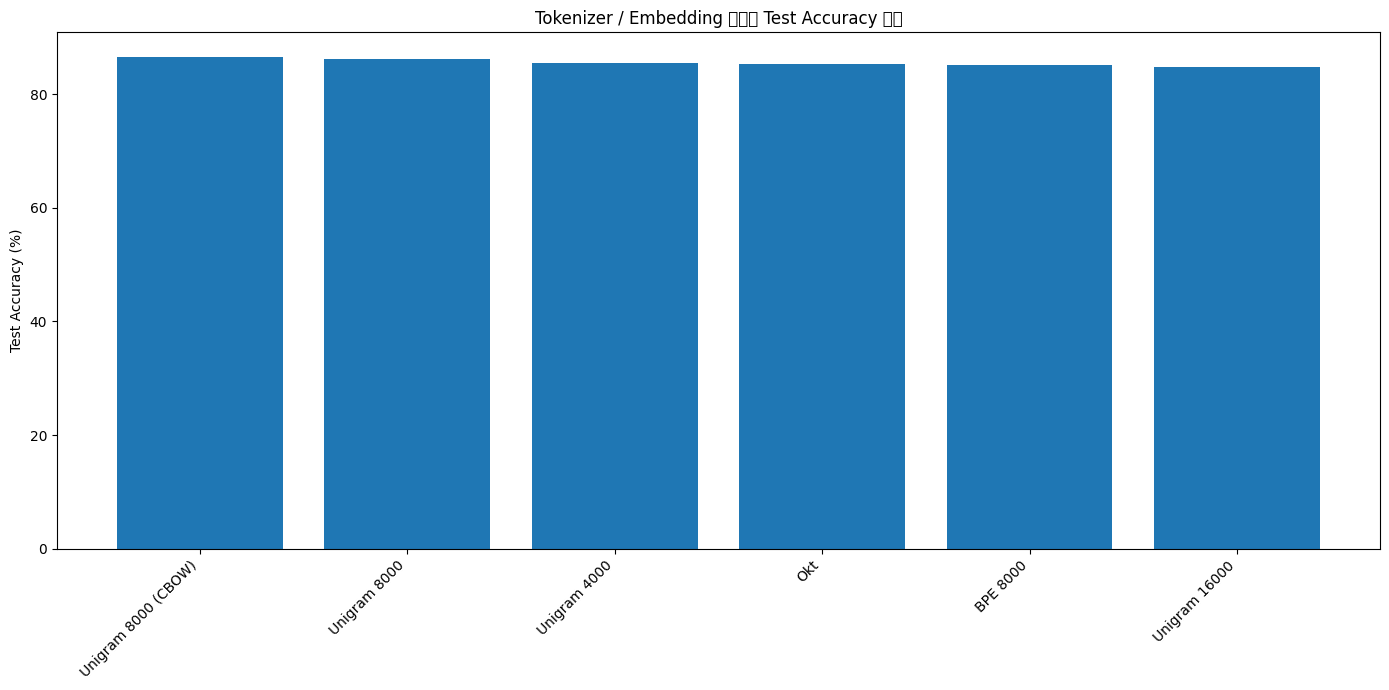


최고 성능 설정 (Word2Vec 포함)
tokenizer         SentencePiece+GloVe-like
config                 Unigram 8000 (CBOW)
vocab_size                            8000
best_valid_acc                    0.867083
test_acc                          0.865686
test_loss                          0.30908
Name: 0, dtype: object


In [ ]:
# ============================================
# 25-7. 모든 실험 결과 통합 및 최종 비교
# ============================================
all_results_with_w2v = sp_results + konlpy_results + sp_w2v_results

df_results_with_w2v = pd.DataFrame([
    {
        "tokenizer": r["tokenizer"],
        "config": r["config"],
        "vocab_size": r["vocab_size"],
        "best_valid_acc": r["best_valid_acc"],
        "test_acc": r["test_acc"],
        "test_loss": r["test_loss"]
    }
    for r in all_results_with_w2v
])

df_results_with_w2v = df_results_with_w2v.sort_values(by="test_acc", ascending=False).reset_index(drop=True)

print("\n최종 비교 결과 (Word2Vec 포함)")
print(df_results_with_w2v)

# 시각화 업데이트
plt.figure(figsize=(14, 7))
plt.bar(df_results_with_w2v["config"], df_results_with_w2v["test_acc"] * 100)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test Accuracy (%)")
plt.title("Tokenizer / Embedding 설정별 Test Accuracy 비교")
plt.tight_layout()
plt.show()

# 최고 성능 설정 업데이트
best_row_w2v = df_results_with_w2v.iloc[0]
print("\n최고 성능 설정 (Word2Vec 포함)")
print(best_row_w2v)

Word2Vec을 적용한 결과 적용한 것이 조금 우세했으나, 결과적으로 큰 차이는 나지 않았다...